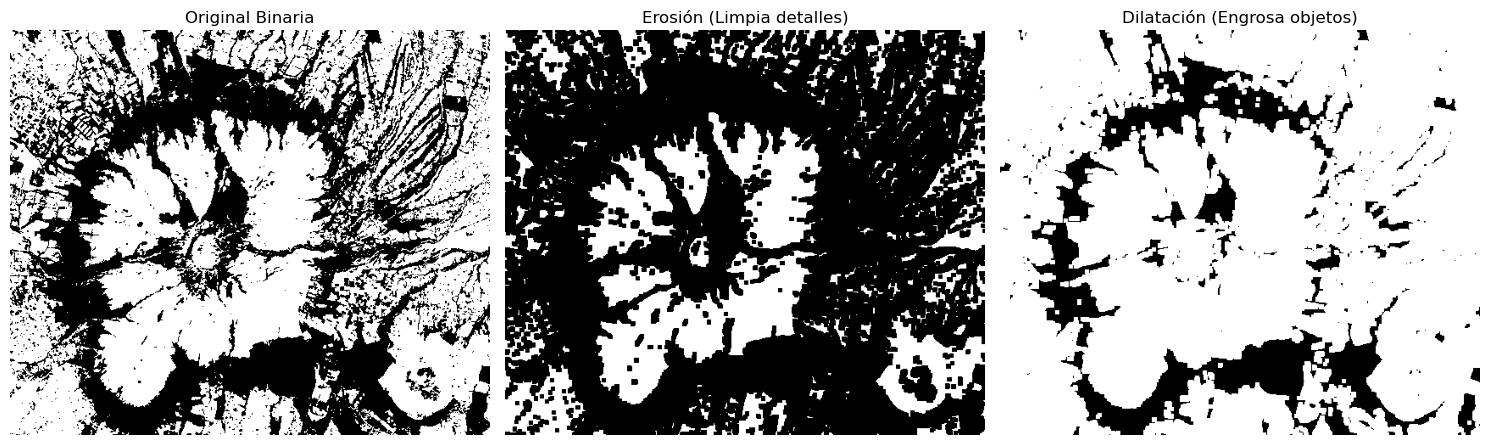

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen satelital
# Cambia la ruta por la ubicación real de tu archivo
img_path = '/home/paul/Documentos/FFT/Data/satelite_1.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Si la imagen no carga, creamos una de respaldo para que el código no falle
if img is None:
    img = np.zeros((300, 300), dtype=np.uint8)
    cv2.putText(img, 'Sat-1', (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 3, 255, 5)

# Paso previo: Binarización (para que la morfología sea clara)
_, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Definir el Kernel
kernel = np.ones((5, 5), np.uint8)

# 3. EROSIÓN
erosion = cv2.erode(img_bin, kernel, iterations=1)

# 4. DILATACIÓN
dilation = cv2.dilate(img_bin, kernel, iterations=1)

# --- Visualización ---
titles = ['Original Binaria', 'Erosión (Limpia detalles)', 'Dilatación (Engrosa objetos)']
images = [img_bin, erosion, dilation]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Erosión y Dilatación en Python

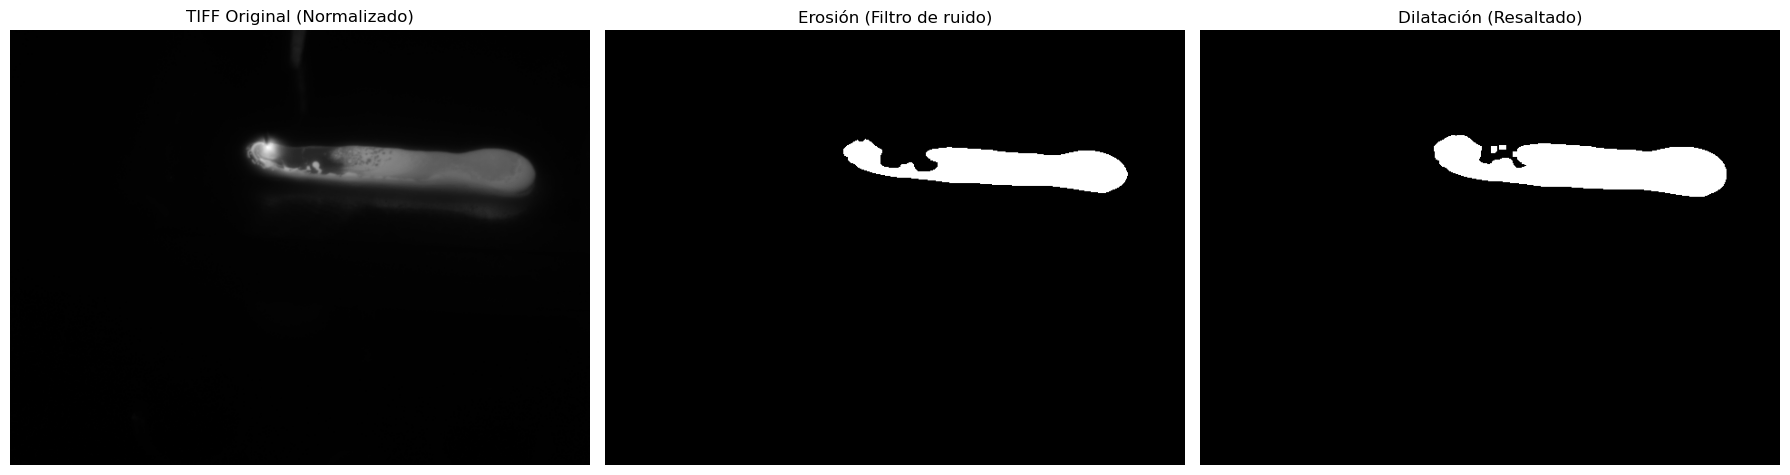

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen TIFF
# Usamos IMREAD_UNCHANGED para no perder la profundidad de bits (16-bit, etc.)
img_path = '/home/paul/Documentos/FFT/Data/ir.tif'
img_tiff = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

# 2. Normalización (Paso crítico para TIFF)
# Convertimos cualquier rango (ej. 0-65535) a 0-255 para poder procesar con OpenCV estándar
img_8bit = cv2.normalize(img_tiff, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# 3. Binarización para Morfología
_, binary = cv2.threshold(img_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Operaciones Morfológicas
kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)

# --- Visualización ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_8bit, cmap='gray'); axes[0].set_title('TIFF Original (Normalizado)')
axes[1].imshow(erosion, cmap='gray'); axes[1].set_title('Erosión (Filtro de ruido)')
axes[2].imshow(dilation, cmap='gray'); axes[2].set_title('Dilatación (Resaltado)')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## ocr

In [8]:
!pip install pytesseract


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import pytesseract

En cv2.medianBlur(src, ksize):
src: La imagen de entrada (en este caso, la versión en gris).

ksize: El tamaño de la ventana (kernel). Debe ser un entero impar (3, 5, 7...). A diferencia del desenfoque normal, el de mediana es excelente para eliminar puntos blancos/negros sin borrar los bordes de las letras. Un 3 es ideal para texto pequeño.

En cv2.adaptiveThreshold(...) (Repaso de ajuste fino):
blockSize=11: Define el tamaño del "vecindario" para decidir si un píxel es texto o fondo. Si el texto es muy grande o la imagen tiene mucha resolución, sube este valor a 21 o 31.

C=2: Es la resta constante. Si ves que el fondo sale con muchas manchas negras, aumenta este valor (por ejemplo a 5 o 7) para "limpiar" más agresivamente.

--- TEXTO DETECTADO ---


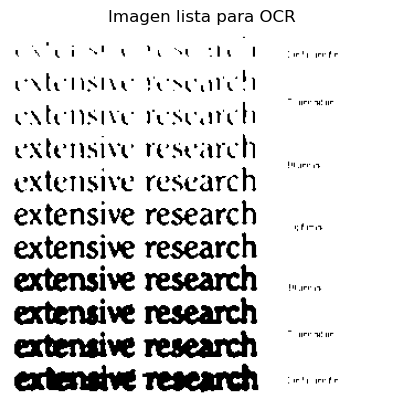

In [16]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

# 1. Cargar la imagen
img = cv2.imread('/home/paul/Documentos/FFT/Data/eng_bright.png')

# 2. Preprocesamiento
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Eliminar ruido (Suavizado)
blurred = cv2.medianBlur(gray, 3)

# 4. Umbralizado Adaptativo para resaltar el texto
processed_img = cv2.adaptiveThreshold(
    blurred, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 
    25, 
    10
)

# # 5. Extraer el texto con Tesseract
# texto_extraido = pytesseract.image_to_string(processed_img, lang='spa')

print("--- TEXTO DETECTADO ---")
# print(texto_extraido)

# Visualización
plt.imshow(processed_img, cmap='gray')
plt.title('Imagen lista para OCR')
plt.axis('off')
plt.show()

# watershead

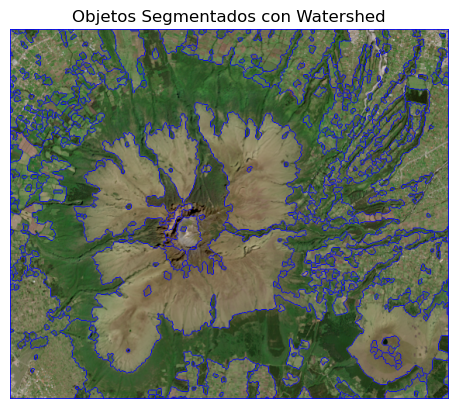

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar y binarizar
img = cv2.imread('/home/paul/Documentos/FFT/Data/satelite_1.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Limpieza de ruido
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# 3. Encontrar el área segura del fondo
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. Encontrar el área segura del objeto (Foreground)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.min(), 255, 0)

# 5. Encontrar la región desconocida
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Marcadores
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# 7. Aplicar Watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0] # Pintamos los bordes de rojo

# Visualización
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Objetos Segmentados con Watershed')
plt.axis('off')
plt.show()

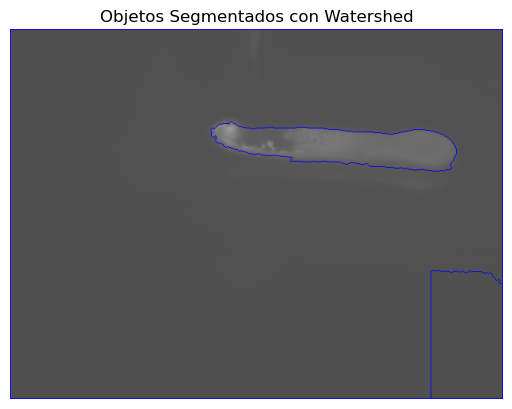

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar y binarizar
img = cv2.imread('/home/paul/Documentos/FFT/Data/ir.tif')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Limpieza de ruido
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# 3. Encontrar el área segura del fondo
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. Encontrar el área segura del objeto (Foreground)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# 5. Encontrar la región desconocida
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Marcadores
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# 7. Aplicar Watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0] # Pintamos los bordes de rojo

# Visualización
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Objetos Segmentados con Watershed')
plt.axis('off')
plt.show()